# Normalization

## Import of required libs

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Data analysis

In [7]:
df = pd.read_csv("wine dataset.csv")
df=df[["class","Alcohol","Magnesium"]]
df

,class,Alcohol,Magnesium
0,1,14.23,127
1,1,13.20,100
2,1,13.16,101
3,1,14.37,113
4,1,13.24,118
...,...,...,...
173,3,13.71,95
174,3,13.40,102
175,3,13.27,120
176,3,13.17,120


<Axes: xlabel='Alcohol', ylabel='Density'>

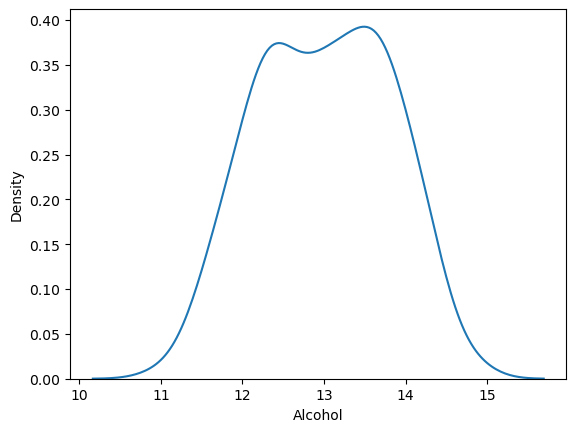

In [9]:
sns.kdeplot(df["Alcohol"])

<Axes: xlabel='Magnesium', ylabel='Density'>

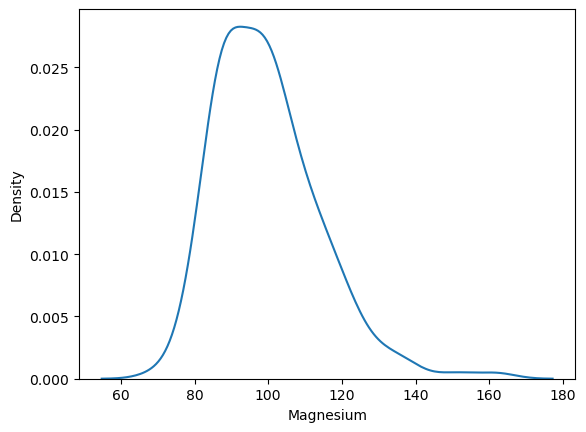

In [10]:
sns.kdeplot(df["Magnesium"])

<Axes: xlabel='Alcohol', ylabel='Magnesium'>

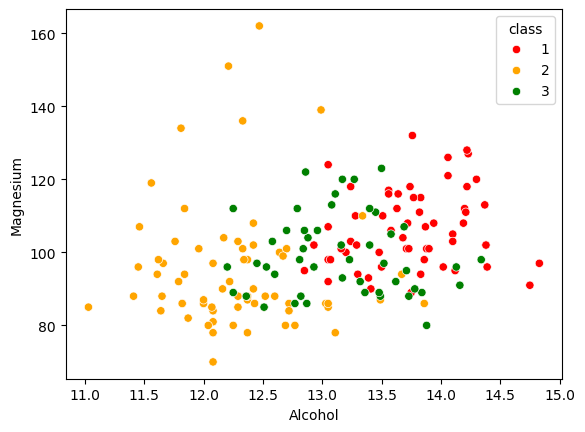

In [42]:
sns.scatterplot(x=df["Alcohol"],y=df["Magnesium"],hue=df["class"],palette={1:"r",2:"orange",3:"g"})

## Data preprocessing

### Train test split 

Train-test split is the process of dividing a dataset into two parts:
one part to train the model and the other part to test its performance.
 * Training Set → Used to teach the model 
 * Testing Set → Used to evaluate the model

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('class', axis=1),
    df['class'],
    test_size=0.3,
    random_state=0
)

X_train.shape, X_test.shape

((124, 2), (54, 2))

### Training the model

* X_train DOES NOT contain class label
* y_train ONLY contains class label
* Important  rule : Rows in X must equal rows in y

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

#fit the scaler to train set , it will learn the parameter 
scaler.fit(X_train)
""" The scaler will :
Calculates minimum value of each column
Calculates maximum value of each column 

Then apply the formula and then it will make the values in the range od 0 to 1
"""

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# transforming the serise into pandas dataset
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

See the difference between the data set before and after scaling

In [40]:
print(X_train.describe(),"\n \n",X_test.describe())

          Alcohol   Magnesium
count  124.000000  124.000000
mean    12.983065  100.088710
std      0.801340   14.659281
min     11.030000   70.000000
25%     12.362500   89.000000
50%     13.040000   98.000000
75%     13.640000  106.250000
max     14.750000  162.000000 
 
          Alcohol   Magnesium
count  54.000000   54.000000
mean   13.040926   98.944444
std     0.841654   13.475928
min    11.410000   78.000000
25%    12.362500   88.000000
50%    13.050000   98.000000
75%    13.720000  110.250000
max    14.830000  132.000000


In [41]:
print(X_train_scaled.describe(),"\n \n",X_test_scaled.describe())

          Alcohol   Magnesium
count  124.000000  124.000000
mean     0.525017    0.327051
std      0.215414    0.159340
min      0.000000    0.000000
25%      0.358199    0.206522
50%      0.540323    0.304348
75%      0.701613    0.394022
max      1.000000    1.000000 
 
          Alcohol  Magnesium
count  54.000000  54.000000
mean    0.540571   0.314614
std     0.226251   0.146477
min     0.102151   0.086957
25%     0.358199   0.195652
50%     0.543011   0.304348
75%     0.723118   0.437500
max     1.021505   0.673913


Data visualization

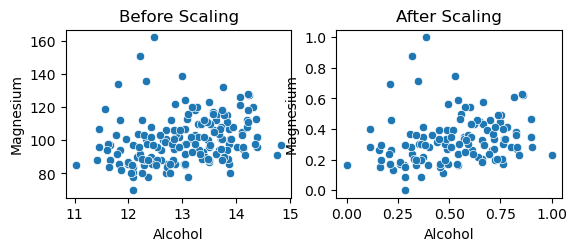

In [56]:
plt.subplot(2,2,1)
sns.scatterplot(x=df["Alcohol"],y=df["Magnesium"])
plt.title("Before Scaling")
plt.subplot(2,2,2)
sns.scatterplot(x=X_train_scaled["Alcohol"],y=X_train_scaled["Magnesium"])
plt.title("After Scaling")
plt.show()

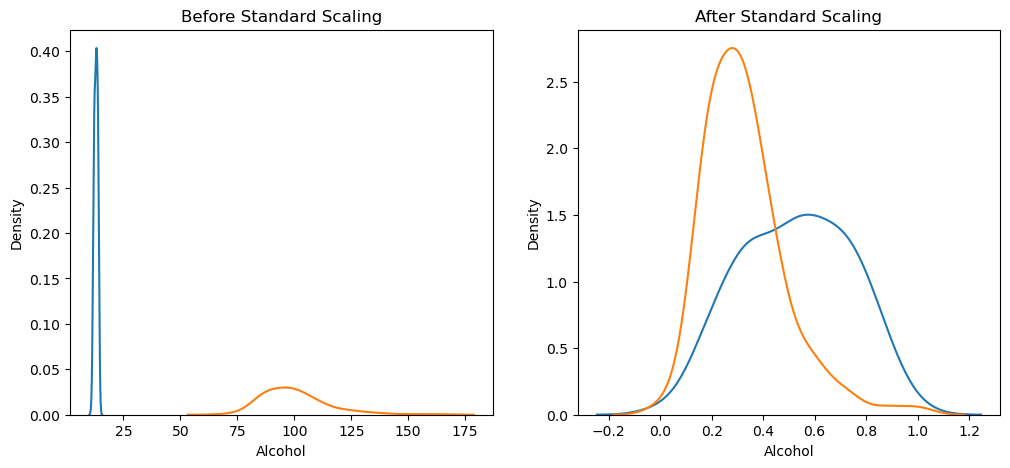

In [58]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Standard Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Magnesium'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Magnesium'], ax=ax2)

plt.show()